In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

import os
os.chdir(r'D:\HKUST\5054_Statistical_Machine_Learning\Assignments\HW4\20newsgroup\20newsgroup')

#  The wordlist.txt lists the 100 key words.
with open('wordlist.txt', 'r') as f:
    wordlist = f.read().splitlines()
with open('groupnames.txt', 'r') as f:
    groupnames = [line.strip() for line in f]
labels = np.loadtxt('newsgroups.txt', dtype=int)

# The documents.txt is essentially a 16242x100 occurrence matrix where each row is corresponding to 1 posting and each column is corresponding to 1 keyword.
rows, cols, data = [], [], []
with open('documents.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        doc_id = int(parts[0]) - 1   # convert to 0-based index
        word_id = int(parts[1]) - 1  # convert to 0-based index
        value = int(parts[2])        # always 1
        rows.append(doc_id)
        cols.append(word_id)
        data.append(value)
        
n_docs = 16242
n_words = 100
X_sparse = csr_matrix((data, (rows, cols)), shape=(n_docs, n_words))
X = X_sparse.toarray()  # Convert to dense array (OK since 16242x100 is small)
y = labels

Best CV accuracy: 0.8117
Best params: {'max_features': 'log2', 'n_estimators': 200}


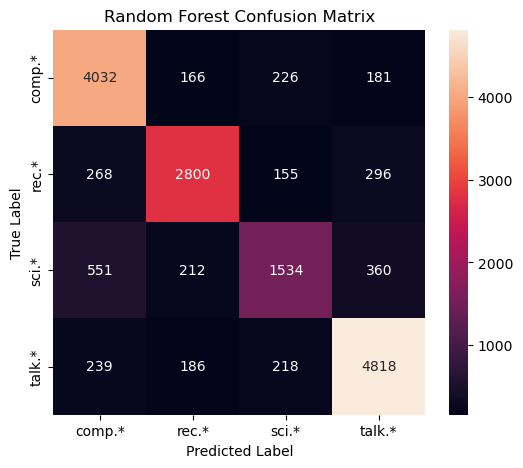


Top 10 important words:
windows: 0.0437
god: 0.0345
car: 0.0331
christian: 0.0322
government: 0.0280
team: 0.0242
jews: 0.0233
graphics: 0.0200
space: 0.0183
religion: 0.0175


In [2]:
# P2_Q1

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 5-fold CV: Use StratifiedKFold to keep class distribution in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3042)

# Define parameter grid
param_grid = {
    'n_estimators': [100,150,175,180,200,225],
    'max_features': ['sqrt', 'log2', None]  # None = use all 100 features
}

rf = RandomForestClassifier(random_state=3042)
grid_search = GridSearchCV(
    rf, param_grid, cv=skf, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X, y)

best_rf = grid_search.best_estimator_
best_score = grid_search.best_score_
print(f"Best CV accuracy: {best_score:.4f}")
print(f"Best params: {grid_search.best_params_}")

# Get confusion matrix on full data via cross_val_predict
from sklearn.model_selection import cross_val_predict
y_pred_rf = cross_val_predict(best_rf, X, y, cv=skf)
cm_rf = confusion_matrix(y, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=groupnames, yticklabels=groupnames)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Get top 10 important words
importances = best_rf.feature_importances_
top10_idx = np.argsort(importances)[::-1][:10]
print("\nTop 10 important words:")
for i in top10_idx:
    print(f"{wordlist[i]}: {importances[i]:.4f}")

Best GB CV accuracy: 0.8223
Best GB CV misclassification error: 0.1777
Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


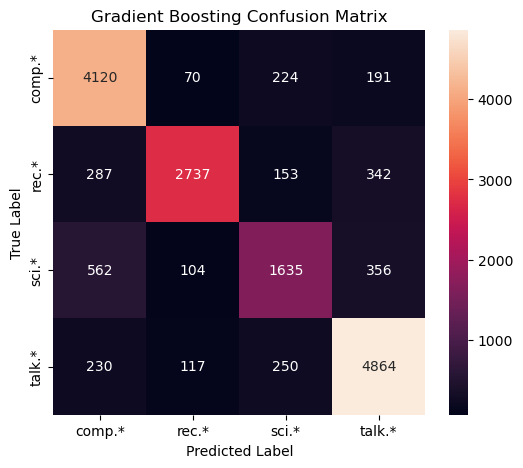

In [5]:
# P2_Q2
from sklearn.ensemble import GradientBoostingClassifier

# Define parameter grid for GB
param_grid_gb = {
    'n_estimators': [100,200],        # Number of trees
    'learning_rate': [0.05, 0.1],      # Step size for each tree
    'max_depth': [3, 5]                # Max depth of each tree (controls complexity)
}

# Initialize GB classifier
gb = GradientBoostingClassifier(random_state=3042)

# Grid search with 5-fold CV
grid_search_gb = GridSearchCV(
    gb, param_grid_gb, cv=skf, scoring='accuracy', n_jobs=-1
)
grid_search_gb.fit(X, y)

# Get best model and score
best_gb = grid_search_gb.best_estimator_
best_score_gb = grid_search_gb.best_score_

# Misclassification error = 1 - accuracy
misclassification_error_gb = 1 - best_score_gb

print(f"Best GB CV accuracy: {best_score_gb:.4f}")
print(f"Best GB CV misclassification error: {misclassification_error_gb:.4f}")
print(f"Best GB params: {grid_search_gb.best_params_}")

# Get predictions via cross_val_predict (no data leakage)
y_pred_gb = cross_val_predict(best_gb, X, y, cv=skf)

# Confusion matrix
cm_gb = confusion_matrix(y, y_pred_gb)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_gb, annot=True, fmt='d', xticklabels=groupnames, yticklabels=groupnames)
plt.title('Gradient Boosting Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### **P2_Q3: Comparison of Random Forest and Gradient Boosting**

| Model               | CV Accuracy | Misclassification Error | Best Parameters |
|---------------------|-------------|--------------------------|------------------|
| Random Forest       | 0.8117      | 0.1883                   | `{'n_estimators': 200, 'max_features': 'log2'}` |
| Gradient Boosting   | 0.8223      | 0.1777                   | `{'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 5}` |

- Gradient Boosting achieves **slightly lower error** (17.77% vs. 18.83%).
- Both models confuse **`rec.`** and **`sci.`** due to overlapping keywords.
- GB uses deeper trees (`max_depth=5`) and is more sensitive to tuning; RF is simpler and more robust.
- GB outperforms RF marginally, but at higher computational cost.


LDA CV accuracy: 0.7985
LDA CV misclassification error: 0.2015


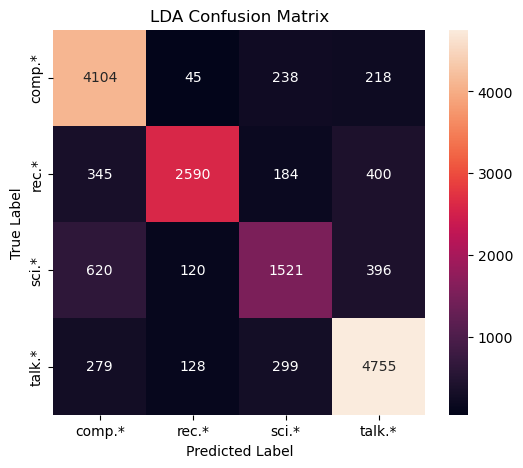

In [6]:
# P2_Q4
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, cross_val_predict

# Initialize LDA
lda = LinearDiscriminantAnalysis()

# 5-fold CV accuracy
lda_scores = cross_val_score(lda, X, y, cv=skf, scoring='accuracy')
lda_mean_acc = lda_scores.mean()
lda_error = 1 - lda_mean_acc

print(f"LDA CV accuracy: {lda_mean_acc:.4f}")
print(f"LDA CV misclassification error: {lda_error:.4f}")

# Get predictions for confusion matrix
y_pred_lda = cross_val_predict(lda, X, y, cv=skf)
cm_lda = confusion_matrix(y, y_pred_lda)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_lda, annot=True, fmt='d', xticklabels=groupnames, yticklabels=groupnames)
plt.title('LDA Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

QDA CV accuracy: 0.6882
QDA CV misclassification error: 0.3118


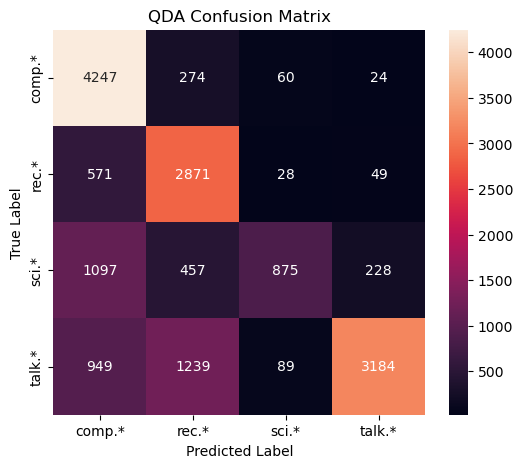

In [10]:
# P2_Q5
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

qda = QuadraticDiscriminantAnalysis()
qda_scores = cross_val_score(qda, X, y, cv=skf, scoring='accuracy')
qda_mean_acc = qda_scores.mean()
qda_error = 1 - qda_mean_acc

print(f"QDA CV accuracy: {qda_mean_acc:.4f}")
print(f"QDA CV misclassification error: {qda_error:.4f}")

y_pred_qda = cross_val_predict(qda, X, y, cv=skf)
cm_qda = confusion_matrix(y, y_pred_qda)

plt.figure(figsize=(6,5))
sns.heatmap(cm_qda, annot=True, fmt='d', xticklabels=groupnames, yticklabels=groupnames)
plt.title('QDA Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()





### **P2_Q6: Compare the performances of all above methods**

| Method               | CV Accuracy | Misclassification Error |
|----------------------|-------------|--------------------------|
| Random Forest        | 0.8117      | 0.1883                   |
| Gradient Boosting    | 0.8223      | 0.1777                   |
| LDA                  | 0.7985      | 0.2015                   |
| QDA                  | 0.6882      | 0.3118                   |

- **Gradient Boosting** achieves the **lowest error** (17.77%), followed closely by **Random Forest** (18.83%).
- **LDA** performs reasonably well (20.15% error) despite the binary feature violation of its Gaussian assumption.
- **QDA performs significantly worse** (31.18% error), likely due to:
  - High feature dimensionality (100) relative to sample size per class,
  - Singular or near-singular within-class covariance matrices,
  - Strong violation of Gaussian assumption with binary features.
- Tree-based methods (**RF/GB**) clearly outperform generative models (**LDA/QDA**) on this sparse binary text representation, as they make **no distributional assumptions** and handle feature interactions naturally.
